# SOC LEAFs Conservation Tillage
The RothC model [Colemna, Prout & Milne (2024)](https://www.rothamsted.ac.uk/sites/default/files/Documents/RothC_description.pdf) in its current state was developed to account for the effects of traditional tillage, but not of conservation tillage. [Hyun & Yoo (2024)](https://doi.org/10.1016/j.scitotenv.2023.168010) adapted the model by developing Reduced Tillage Modifier (RTMs), derived by analyzing 210 plot field studies around the globe. RTMs are an extra multiplying factor influencing the decaying/transfer rate of each SOC pool, and are dependent on initial SOC and sand content of the soil. The mean values can be summarized as:

<table border="1" cellpadding="6" cellspacing="0" style="text-align: center;">
  <thead>
    <tr>
      <th></th>
      <th colspan="4" style="text-align: center;">Sand Content</th>
    </tr>
    <tr>
      <th></th>
      <th colspan="2" style="text-align: center;">&gt; 37.6</th>
      <th colspan="2" style="text-align: center;">&le; 37.6</th>
    </tr>
    <tr>
      <th></th>
      <th colspan="2" style="text-align: center;">SOC Content</th>
      <th colspan="2" style="text-align: center;">Sand Content</th>
    </tr>
    <tr>
      <th></th>
      <th>&gt; 75.7</th>
      <th>&le; 75.7</th>
      <th>&gt; 35</th>
      <th>&le; 36</th>
    </tr>
    <tr>
      <th>C Pool</th>
      <th style="text-align: center;">TN1</th>
      <th style="text-align: center;">TN2</th>
      <th style="text-align: center;">TN3</th>
      <th style="text-align: center;">TN3</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>DPM</strong></td>
      <td>1.54</td>
      <td>1.71</td>
      <td>1.54</td>
      <td>0.72</td>
    </tr>
    <tr>
      <td><strong>RPM</strong></td>
      <td>0.35</td>
      <td>0.35</td>
      <td>2.15</td>
      <td>0.97</td>
    </tr>
    <tr>
      <td><strong>BIO</strong></td>
      <td>1.42</td>
      <td>0.38</td>
      <td>2.38</td>
      <td>0.99</td>
    </tr>
    <tr>
      <td><strong>HUM</strong></td>
      <td>0.42</td>
      <td>0.87</td>
      <td>2.93</td>
      <td>0.94</td>
    </tr>
  </tbody>
</table>


These have been implemented on the RothC model available in this repository, and can be included by simply defining the parameter `red_till = True` when running the function `rothc.run_RothC_crops`. The model, using the baseline data sourced from SoilGrids, will automatically decide which set of RTMs to apply in the calculations. 

## Conservation Tillage Scenarios
SOC LEAFs have been calculated for the following crops and scenarios, and can be used to assess the local benefits of it when compared to the already calculated traditional tillage scenarios

| Crop      | Irrigation Method | Residue Management |
|:----------|:-----------------:|:------------------:|
| Barley    | Rainfed           | Removed from field |
| Barley    | Rainfed           | Left on the field |
| Barley    | Irrigated           | Removed from field |
| Barley    | Irrigated           | Removed from field |
| Cotton    | Rainfed           | Not Applicable |
| Cotton    | Irrigated           | Not Applicable  |
| Maize    | Rainfed           | Removed from field |
| Maize    | Rainfed           | Left on the field |
| Maize    | Irrigated           | Removed from field |
| Maize    | Irrigated           | Removed from field |
| Rapeseed    | Rainfed           | Removed from field |
| Rapeseed    | Rainfed           | Left on the field |
| Rapeseed    | Irrigated           | Removed from field |
| Rapeseed    | Irrigated           | Removed from field |
| Sorghum    | Rainfed           | Removed from field |
| Sorghum    | Rainfed           | Left on the field |
| Sorghum    | Irrigated           | Removed from field |
| Sorghum    | Irrigated           | Removed from field |
| Soybean    | Rainfed           | Not Applicable |
| Soybean    | Irrigated           | Not Applicable |
| Sunflower    | Rainfed           | Not Applicable |
| Sunflower    | Irrigated           | Not Applicable |
| Wheat    | Rainfed           | Removed from field |
| Wheat    | Rainfed           | Left on the field |
| Wheat    | Irrigated           | Removed from field |
| Wheat    | Irrigated           | Removed from field |

The scenarios and their parameters have been summarized in the [annual_crops_reduced_tillage_rothc_scenarios.xlsx](../data/crops/rothc_support/annual_crops_reduced_tillage_rothc_scenarios.xlsx) file.

## Running RothC

In [1]:
# Modules
import sbtn_leaf.RothC_Raster as rothc
import sbtn_leaf.map_plotting as mp
import sbtn_leaf.map_calculations as mc
import polars as pl
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parents[0]
rasters_folder = project_root/"LEAFs/SOC/rasters_clipped/reduced_tillage"
rasters_folder_ct = project_root/"LEAFs/SOC/rasters_clipped"
q_breaks = [0,10,30,50,70,90,110,200]

Could not determine dtype for column 1, falling back to string


In [2]:
# Files
scenarios_fp = '../data/crops/rothc_support/annual_crops_reduced_tillage_rothc_scenarios.xlsx'
scenarios = pl.read_excel(scenarios_fp)
scenarios.head()

Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string
Could not determine dtype for column 27, falling back to string
Could not determine dtype for column 28, falling back to string


crop_name,commodity_type,irr_yield_scaling,practices_string_id,n_years,save_folder,data_description,lu_fp,evap_fp,pc_fp,irr_fp,pr_fp,fym_fp,red_till,save_CO2,residue_runs,ylds_crop_raster,ylds_all_fp,ylds_irr_fp,ylds_rf_fp,force_new_file,ylds_src,outlier_strategy,percentile_bound,apply_local_zscore,apply_soc_clip,soc_global_percentile_cap,max_annual_soc_gain,max_soc_tc_ha,yield_global_percentile_cap
str,str,str,str,i64,str,str,str,str,str,str,str,str,bool,bool,i64,str,str,str,str,bool,str,str,str,bool,bool,f64,str,str,f64
"""Barley""","""annual_crop""","""irr""","""irr_ron_rt""",14,"""../LEAFs/SOC/rasters_clipped/r…","""RothC results for year 2030 fo…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",null,null,true,false,100,"""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",false,"""GAEZ""","""log_winsor""","""(1.0, 99.0)""",true,true,99.5,null,null,99.5
"""Barley""","""annual_crop""","""irr""","""irr_roff_rt""",14,"""../LEAFs/SOC/rasters_clipped/r…","""RothC results for year 2030 fo…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",null,null,true,false,100,"""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",false,"""GAEZ""","""log_winsor""","""(1.0, 99.0)""",true,true,99.5,null,null,99.5
"""Barley""","""annual_crop""","""rf""","""rf_ron_rt""",14,"""../LEAFs/SOC/rasters_clipped/r…","""RothC results for year 2030 fo…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",null,null,null,true,false,100,"""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",false,"""GAEZ""","""log_winsor""","""(1.0, 99.0)""",true,true,99.5,null,null,99.5
"""Barley""","""annual_crop""","""rf""","""rf_roff_rt""",14,"""../LEAFs/SOC/rasters_clipped/r…","""RothC results for year 2030 fo…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",null,null,null,true,false,100,"""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",false,"""GAEZ""","""log_winsor""","""(1.0, 99.0)""",true,true,99.5,null,null,99.5
"""Cotton""","""annual_crop""","""irr""","""irr_rt""",14,"""../LEAFs/SOC/rasters_clipped/r…","""RothC results for year 2030 fo…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",null,null,true,false,100,"""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…","""C:\Users\loyola\OneDrive - Wor…",false,"""GAEZ""","""log_winsor""","""(1.0, 99.0)""",true,true,99.5,null,null,99.5


In [18]:
rothc.run_rothc_crops_scenarios_from_excel(scenarios_fp, run_test=False)

Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 12, falling back to string
Could not determine dtype for column 27, falling back to string
Could not determine dtype for column 28, falling back to string


Running Annual crop - Barley - irr_ron_rt
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Barley using 100 stochastic runs


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into ..\LEAFs\SOC\rasters_clipped\reduced_tillage\Barley_irr_ron_rt_2030y_SOC.tif
Annual crop - Barley - irr_ron_rt calculated. Continuing...


Running Annual crop - Barley - irr_roff_rt
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Residues removed. C_inputs are 0's


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

...

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into ..\LEAFs\SOC\rasters_clipped\reduced_tillage\Wheat_irr_roff_rt_2030y_SOC.tif
Annual crop - Wheat - irr_roff_rt calculated. Continuing...


Running Annual crop - Wheat - rf_ron_rt
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Calculating baseline residue inputs for annual Wheat using 100 stochastic runs


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into ..\LEAFs\SOC\rasters_clipped\reduced_tillage\Wheat_rf_ron_rt_2030y_SOC.tif
Annual crop - Wheat - rf_ron_rt calculated. Continuing...


Running Annual crop - Wheat - rf_roff_rt
    Loading environmental data...
    Loading crop data...
    Running RothC...
        Residues removed. C_inputs are 0's


RothC months:   0%|          | 0/168 [00:00<?, ?it/s]

    Clipping SOC output (max gain = None t C/ha/year)...
    RothC results saved into ..\LEAFs\SOC\rasters_clipped\reduced_tillage\Wheat_rf_roff_rt_2030y_SOC.tif
Annual crop - Wheat - rf_roff_rt calculated. Continuing...




### Checking results

In [19]:
Barley_irr_roff_rt_fp = rasters_folder/"Barley_irr_roff_rt_2030y_SOC.tif"
Barley_irr_ron_rt_fp = rasters_folder/"Barley_irr_ron_rt_2030y_SOC.tif"

Raster has 810,984 unique values. Min: 2.74. Max: 119.06
Using quantile edges


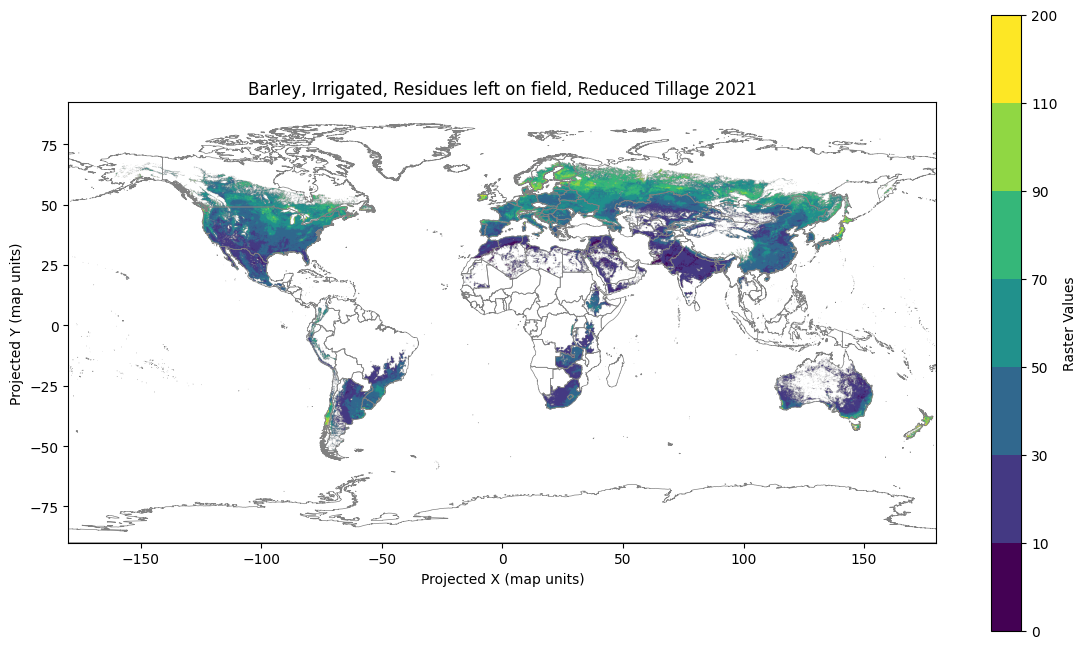

In [22]:
mp.plot_raster_on_world_extremes_cutoff(Barley_irr_ron_rt_fp, "Barley, Irrigated, Residues left on field, Reduced Tillage 2021", raster_band=15, quantiles = q_breaks, perc_cutoff=0)

Raster has 942,119 unique values. Min: 1.63. Max: 94.51
Using quantile edges


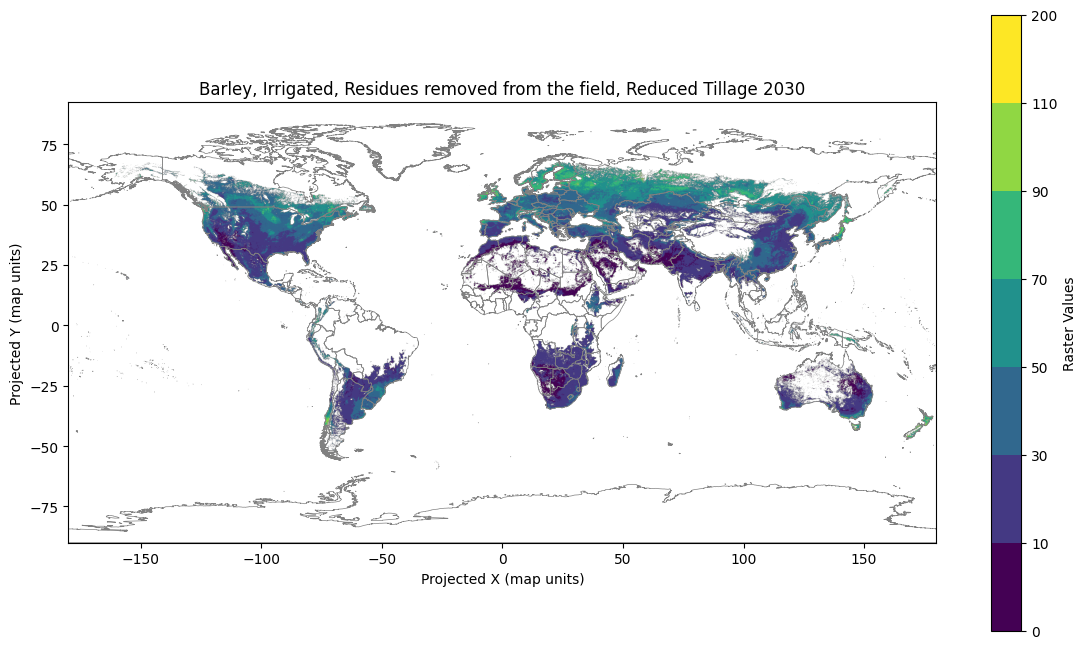

In [23]:
mp.plot_raster_on_world_extremes_cutoff(Barley_irr_roff_rt_fp, "Barley, Irrigated, Residues removed from the field, Reduced Tillage 2030", raster_band=15, quantiles = q_breaks, perc_cutoff=0)

In [29]:
Barley_irr_roff_ct_fp = rasters_folder_ct/"Barley_irr_roff_2030y_SOC.tif"
Barley_irr_ron_ct_fp = rasters_folder_ct/"Barley_irr_ron_2030y_SOC.tif"

Raster has 810,711 unique values. Min: 6.20. Max: 115.01
Using quantile edges


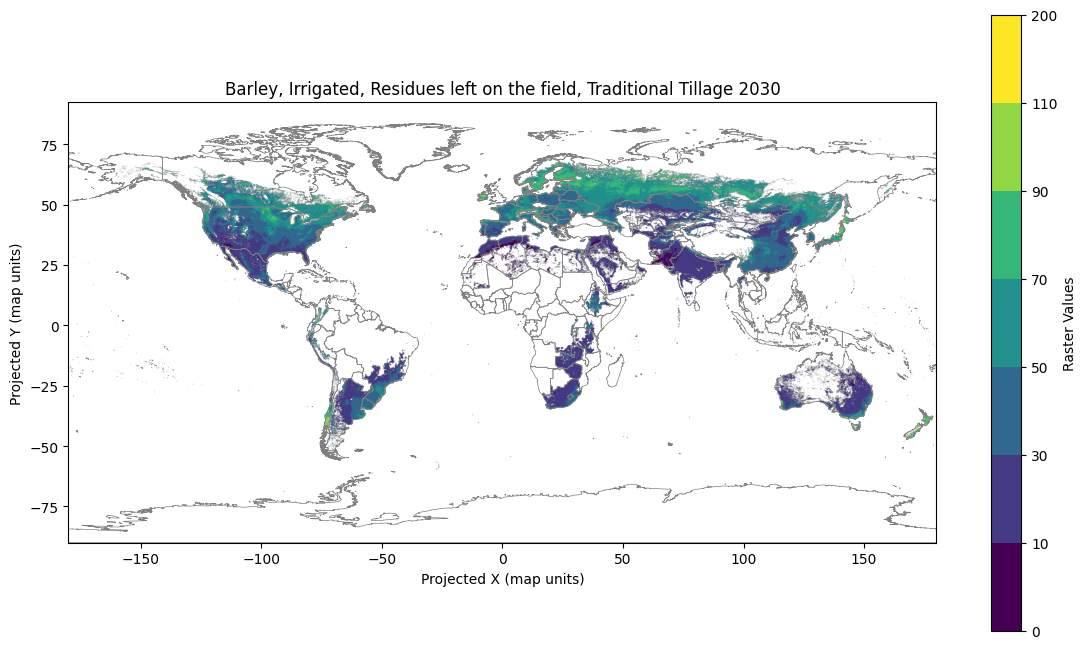

In [31]:
mp.plot_raster_on_world_extremes_cutoff(Barley_irr_ron_ct_fp, "Barley, Irrigated, Residues left on the field, Traditional Tillage 2030", raster_band=15, quantiles = q_breaks, perc_cutoff=0)

Raster has 941,847 unique values. Min: 3.33. Max: 90.39
Using quantile edges


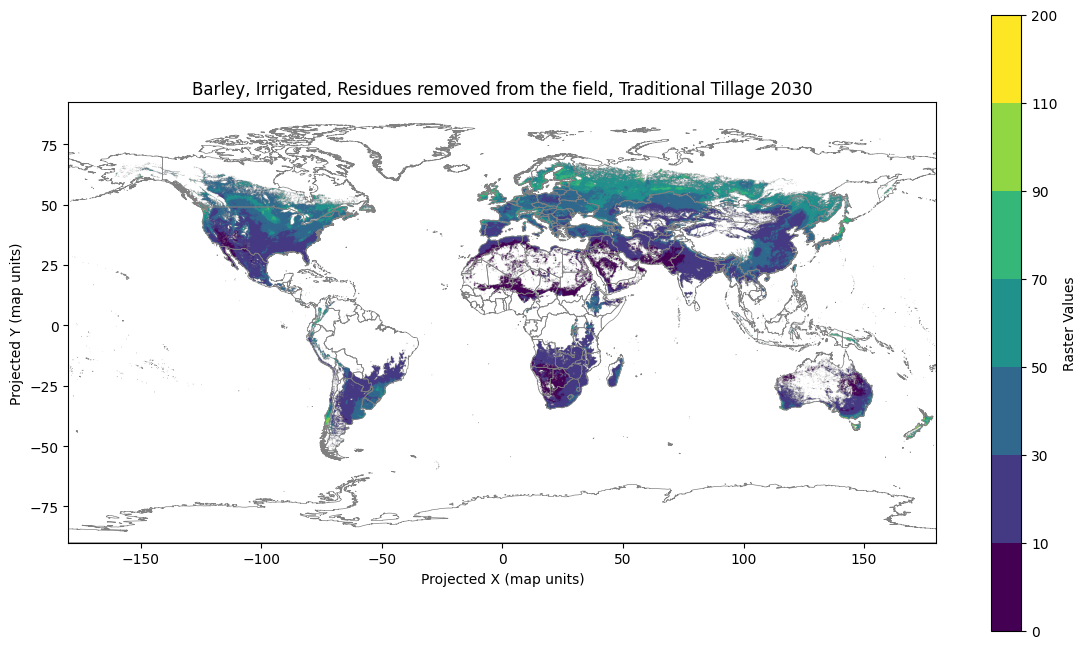

In [32]:
mp.plot_raster_on_world_extremes_cutoff(Barley_irr_roff_ct_fp, "Barley, Irrigated, Residues removed from the field, Traditional Tillage 2030", raster_band=15, quantiles = q_breaks, perc_cutoff=0)

In [33]:
scenarios_tif = [
    Barley_irr_roff_rt_fp,
    Barley_irr_ron_rt_fp,
    Barley_irr_roff_ct_fp,
    Barley_irr_ron_ct_fp,
]
labels = [
    "Irrigated, Residues Off, Reduced Tillage",
    "Irrigated, Residues On, Reduced Tillage",
    "Irrigated, Residues Off, Conv. Tillage",
    "Irrigated, Residues On, Conv. Tillage"
]

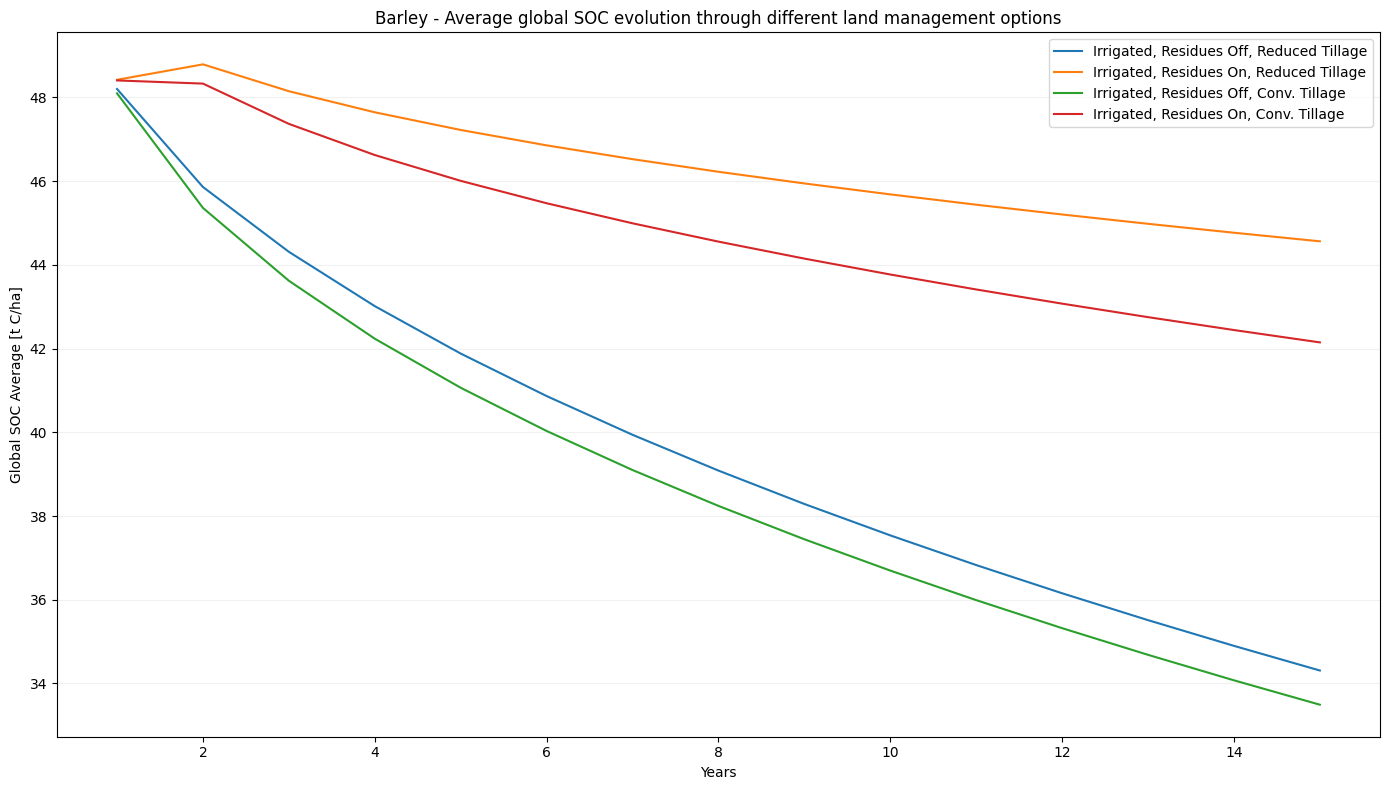

In [34]:
mp.plot_average_band_values(scenarios_tif, labels, "Barley - Average global SOC evolution through different land management options", ylabel="Global SOC Average [t C/ha]",xlabel="Years", show_iq=False)

## Calculating regional averages
Now regional averages need to be calculated, following the same procedure as done for all baseline LEAFs

### Country
Defining needed parameters

In [3]:
# Inputs that stay the same
input_folder = rasters_folder
output_folder = "../LEAFs/SOC/"
cf_name = "SOC_2030"
cf_unit = "t C/ha"
reset_gpck = True
calc_kwargs = dict(raster_band = 15, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99)

In [4]:
# Inputs that change by area type
area_type = "country"
layer_name = "soc_leaf_country"
corrected_shp = gpd.read_file('../data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')
master_key = "ADM0_NAME"
result_key = "country"
gpckg_name = "SOC_2030_reducedtillage_country"

Running country averages

In [5]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    input_folder =str(input_folder),
    output_folder = output_folder,
    layer_name=layer_name,
    master_gdf=corrected_shp,           # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # 'ADM0_NAME', 'ADM1_NAME', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    input_raster_key_startswith=None,
    gpckg_name = gpckg_name,
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=calc_kwargs,     # Chooses the raster band. Due to outliers in crops, setting it to windsorize, replacing all values outside 1, 99 percentiles with those values.
    reset_gpkg=True,
    run_test=False, 
    max_workers=4
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-12 10:55:44,532 - INFO - Building 'soc_leaf_country' from rasters in c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\reduced_tillage into ../LEAFs/SOC/ (../LEAFs/SOC/SOC_2030_reducedtillage_country.gpkg)



Processing rasters (soc_leaf_country):   0%|          | 0/26 [00:00<?, ?raster/s]

2026-05-12 10:56:04,172 - INFO - Calculating SOC_2030 for Barley_irr_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_irr_roff_rt_2030y_SOC...2026-05-12 10:56:04,179 - INFO - Calculating SOC_2030 for Barley_irr_ron_rt_2030y_SOC...

2026-05-12 10:56:04,183 - INFO - Calculating SOC_2030 for Barley_rf_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_irr_ron_rt_2030y_SOC...
2026-05-12 10:56:04,190 - INFO - Calculating SOC_2030 for Barley_rf_ron_rt_2030y_SOC...
Calculating SOC_2030 for Barley_rf_roff_rt_2030y_SOC...

Processing rasters (soc_leaf_country):   0%|          | 0/26 [00:00<?, ?raster/s]


Calculating SOC_2030 for Barley_rf_ron_rt_2030y_SOC...
2026-05-12 11:09:17,033 - INFO - Calculating SOC_2030 for Cotton_irr_rt_2030y_SOC...
Calculating SOC_2030 for Cotton_irr_rt_2030y_SOC...
2026-05-12 11:09:45,272 - INFO - Calculating SOC_2030 for Cotton_rf_rt_2030y_SOC...
Calculating SOC_2030 for Cotton_rf_rt_2030y_SOC...
2026-05-12 11:10:18,918 - INFO - Calculating SOC_2030 for Maize_irr_roff_rt_2030y_SOC...
Calculating SOC_2030 for Maize_irr_roff_rt_2030y_SOC...
2026-05-12 11:10:52,925 - INFO - Calculating SOC_2030 for Maize_irr_ron_rt_2030y_SOC...
Calculating SOC_2030 for Maize_irr_ron_rt_2030y_SOC...
2026-05-12 11:23:18,078 - INFO - Calculating SOC_2030 for Maize_rf_roff_rt_2030y_SOC...
Calculating SOC_2030 for Maize_rf_roff_rt_2030y_SOC...
2026-05-12 11:23:55,861 - INFO - Calculating SOC_2030 for Maize_rf_ron_rt_2030y_SOC...
Calculating SOC_2030 for Maize_rf_ron_rt_2030y_SOC...
2026-05-12 11:25:42,261 - INFO - Calculating SOC_2030 for Rapeseed_irr_roff_rt_2030y_SOC...
Calculat

Wrote 21528 rows into ../LEAFs/SOC/SOC_2030_reducedtillage_country.gpkg


#### Checking results...

In [6]:
gdf_test_values = gpd.read_file(gpkg_path, layer=layer_name)
gdf_test_values.sort_values(by=["cf"], ascending=False).head()

,ADM0_NAME,flow_name,cf,cf_median,cf_std,_source_file
1869,Saint Vincent and the Grenadines,Maize_irr_ron_rt_2030y_SOC,137.439636,137.439636,0.000000e+00,Maize_irr_ron_rt_2030y_SOC.tif
1676,Bahamas,Maize_irr_ron_rt_2030y_SOC,134.175858,136.104630,4.305323e+00,Maize_irr_ron_rt_2030y_SOC.tif
1817,Mauritius,Maize_irr_ron_rt_2030y_SOC,131.695892,132.172806,3.907852e+00,Maize_irr_ron_rt_2030y_SOC.tif
5933,Kuril islands,Wheat_irr_ron_rt_2030y_SOC,121.802322,121.802322,1.421085e-14,Wheat_irr_ron_rt_2030y_SOC.tif
2697,Saint Vincent and the Grenadines,Maize_rf_ron_rt_2030y_SOC,121.064194,121.064194,1.421085e-14,Maize_rf_ron_rt_2030y_SOC.tif


Merging geometries

In [7]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM0_NAME")

Plotting one crop

In [8]:
country_leafs_check = gdf_test[gdf_test["flow_name"]=="Wheat_irr_ron_rt_2030y_SOC"]

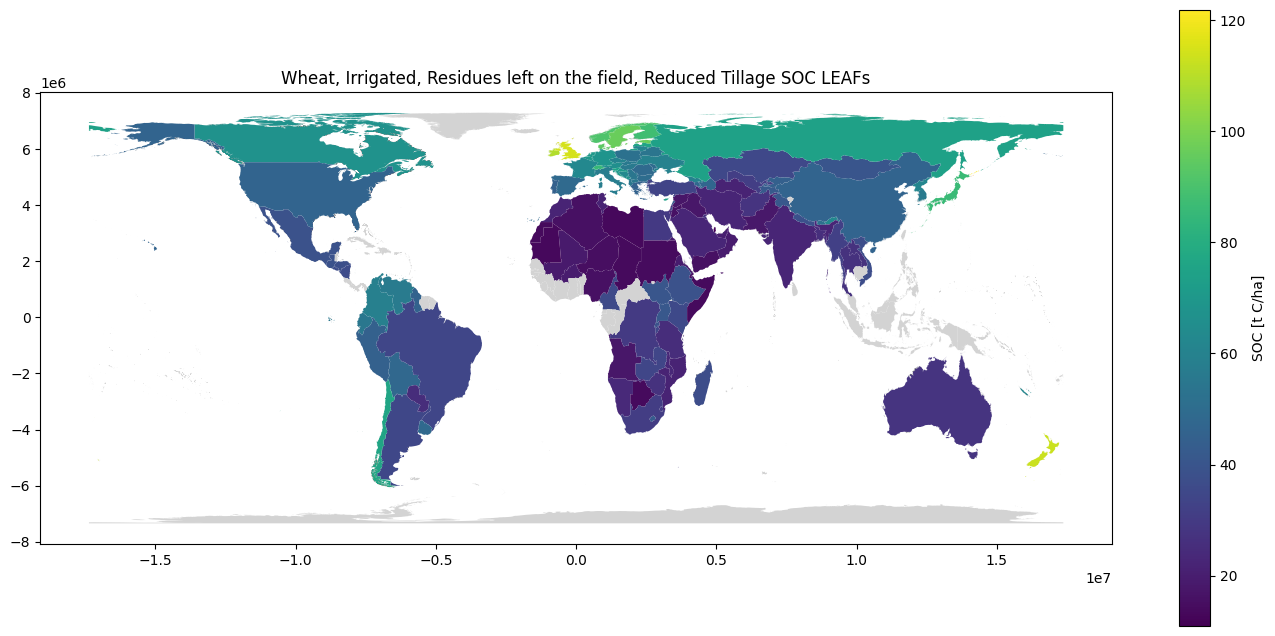

In [9]:
fig, ax = plt.subplots(figsize=(14, 8)) 
country_leafs_check.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Wheat, Irrigated, Residues left on the field, Reduced Tillage SOC LEAFs")
plt.tight_layout() 
plt.show()

Cheching csv

In [10]:
df_results.sort_values(by="value", ascending=False).head(10)

,ADM0_NAME,flow_name,metric,value
5181,Saint Vincent and the Grenadines,Maize_irr_ron_rt_2030y_SOC,cf_mean,137.439640
5457,Saint Vincent and the Grenadines,Maize_irr_ron_rt_2030y_SOC,cf_median,137.439640
5264,Bahamas,Maize_irr_ron_rt_2030y_SOC,cf_median,136.104630
4988,Bahamas,Maize_irr_ron_rt_2030y_SOC,cf_mean,134.175860
5405,Mauritius,Maize_irr_ron_rt_2030y_SOC,cf_median,132.172800
5129,Mauritius,Maize_irr_ron_rt_2030y_SOC,cf_mean,131.695890
21050,Egypt,Wheat_rf_ron_rt_2030y_SOC,cf_median,126.913055
5424,New Caledonia,Maize_irr_ron_rt_2030y_SOC,cf_median,123.771164
17801,Kuril islands,Wheat_irr_ron_rt_2030y_SOC,cf_median,121.802320
17525,Kuril islands,Wheat_irr_ron_rt_2030y_SOC,cf_mean,121.802320


Same values as those on gpckg. All looks ok

### Subcountries
Now proceeding, same as for countries, with sub-country regions.

Loading the necessary data and parameters

In [11]:
# Inputs that change by area type
area_type = "subcountry"
layer_name = "soc_leaf_subcountry"
corrected_shp = gpd.read_file('../data/CountryLayers/SubCountry_Level1/g2015_2014_1.shp')
master_key = "ADM1_CODE"
result_key = "ADM1_CODE"
gpckg_name = "SOC_2030_reducedtillage_subcountry"

Running the averages

In [12]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    input_folder =str(input_folder),
    output_folder = output_folder,
    layer_name=layer_name,
    master_gdf=corrected_shp,
    master_key=master_key,           
    result_key=result_key,              
    gpckg_name = gpckg_name,
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=calc_kwargs,     
    reset_gpkg=True,
    run_test=False,
    max_workers=4,
    checkpoint_every=5              
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-12 12:25:58,259 - INFO - Building 'soc_leaf_subcountry' from rasters in c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\reduced_tillage into ../LEAFs/SOC/ (../LEAFs/SOC/SOC_2030_reducedtillage_subcountry.gpkg)



Processing rasters (soc_leaf_subcountry):   0%|          | 0/26 [00:00<?, ?raster/s]

2026-05-12 12:26:32,808 - INFO - Calculating SOC_2030 for Barley_irr_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_irr_roff_rt_2030y_SOC...2026-05-12 12:26:32,812 - INFO - Calculating SOC_2030 for Barley_irr_ron_rt_2030y_SOC...

2026-05-12 12:26:32,820 - INFO - Calculating SOC_2030 for Barley_rf_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_irr_ron_rt_2030y_SOC...2026-05-12 12:26:32,826 - INFO - Calculating SOC_2030 for Barley_rf_ron_rt_2030y_SOC...

--- Logging error ---


Processing rasters (soc_leaf_subcountry):   0%|          | 0/26 [00:00<?, ?raster/s]

Traceback (most recent call last):
  File "c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\.venv\Lib\site-packages\tqdm\contrib\logging.py", line 27, in emit
    self.tqdm_class.write(msg, file=self.stream)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\.venv\Lib\site-packages\tqdm\std.py", line 720, in write
    with cls.external_write_mode(file=file, nolock=nolock):
         ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\loyola\AppData\Local\Programs\Python\Python313\Lib\contextlib.py", line 148, in __exit__
    next(self.gen)
    ~~~~^^^^^^^^^^
  File "c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\.venv\Lib\site-packages\tqdm\std.py", line 750, in external_write_mode
    inst.refresh(nolock=True)
    ~~~~~~~~~~~~^^^^^^^^^^^^^
  File "c:\Users\loyola\OneDrive - World Wildl

Wrote 266916 rows into ../LEAFs/SOC/SOC_2030_reducedtillage_subcountry.gpkg


#### Checking results

In [13]:
gdf_test_values = gpd.read_file(gpkg_path, layer=layer_name)
gdf_test_values.sort_values(by=["cf"], ascending=False).head()

,ADM1_CODE,flow_name,cf,cf_median,cf_std,_source_file
23897,472,Maize_irr_ron_rt_2030y_SOC,137.439636,137.439636,0.0,Maize_irr_ron_rt_2030y_SOC.tif
21530,61290,Maize_irr_ron_rt_2030y_SOC,137.439636,137.439636,0.0,Maize_irr_ron_rt_2030y_SOC.tif
22738,3400,Maize_irr_ron_rt_2030y_SOC,137.439636,137.439636,0.0,Maize_irr_ron_rt_2030y_SOC.tif
22740,3402,Maize_irr_ron_rt_2030y_SOC,137.439636,137.439636,0.0,Maize_irr_ron_rt_2030y_SOC.tif
21528,61288,Maize_irr_ron_rt_2030y_SOC,137.439636,137.439636,0.0,Maize_irr_ron_rt_2030y_SOC.tif


In [14]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM1_CODE")

Plotting one crop

In [15]:
subcountry_leafs_check = gdf_test[gdf_test["flow_name"]=="Wheat_irr_ron_rt_2030y_SOC"]

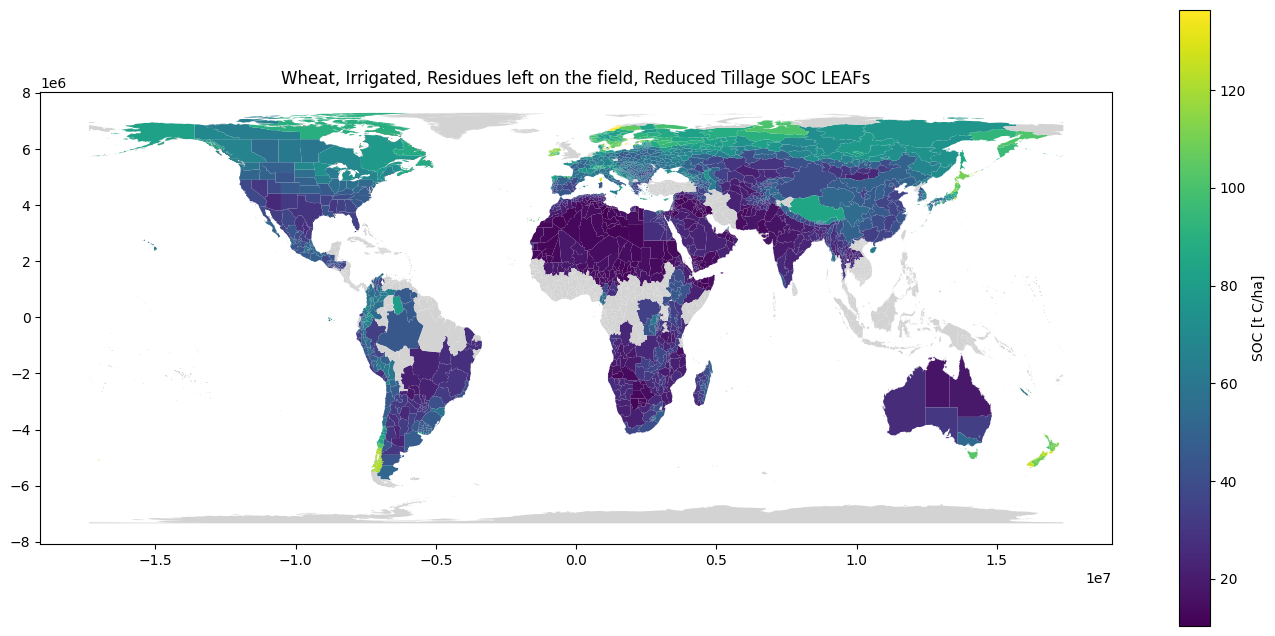

In [16]:
fig, ax = plt.subplots(figsize=(14, 8)) 
subcountry_leafs_check.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Wheat, Irrigated, Residues left on the field, Reduced Tillage SOC LEAFs")
plt.tight_layout() 
plt.show()

### Ecoregions
Finally, ecoregions

In [17]:
# Inputs that change by area type
area_type = "ecoregion"
layer_name = "soc_leaf_ecoregions"
master_key = "ECO_ID"
result_key = "er_id"
gpckg_name = "SOC_2030_reducedtillage_ecoregions"
er_gdf = gpd.read_file("../data/Ecoregions2017/Ecoregions2017.shp")

In [18]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    input_folder =str(input_folder),
    output_folder = output_folder,
    layer_name=layer_name,
    master_gdf=er_gdf,       
    master_key=master_key,       
    result_key=result_key,
    gpckg_name = gpckg_name,
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=calc_kwargs,     
    reset_gpkg=True,
    run_test=False,
    max_workers=4
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-12 13:03:17,033 - INFO - Building 'soc_leaf_ecoregions' from rasters in c:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\LEAFs\SOC\rasters_clipped\reduced_tillage into ../LEAFs/SOC/ (../LEAFs/SOC/SOC_2030_reducedtillage_ecoregions.gpkg)



Processing rasters (soc_leaf_ecoregions):   0%|          | 0/26 [00:00<?, ?raster/s]

2026-05-12 13:03:21,255 - INFO - Calculating SOC_2030 for Barley_irr_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_irr_roff_rt_2030y_SOC...2026-05-12 13:03:21,257 - INFO - Calculating SOC_2030 for Barley_irr_ron_rt_2030y_SOC...

2026-05-12 13:03:21,258 - INFO - Calculating SOC_2030 for Barley_rf_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_irr_ron_rt_2030y_SOC...
2026-05-12 13:03:21,259 - INFO - Calculating SOC_2030 for Barley_rf_ron_rt_2030y_SOC...


Processing rasters (soc_leaf_ecoregions):   0%|          | 0/26 [00:00<?, ?raster/s]

Calculating SOC_2030 for Barley_rf_roff_rt_2030y_SOC...
Calculating SOC_2030 for Barley_rf_ron_rt_2030y_SOC...
2026-05-12 13:09:04,418 - INFO - Calculating SOC_2030 for Cotton_irr_rt_2030y_SOC...
Calculating SOC_2030 for Cotton_irr_rt_2030y_SOC...
2026-05-12 13:09:10,510 - INFO - Calculating SOC_2030 for Cotton_rf_rt_2030y_SOC...
Calculating SOC_2030 for Cotton_rf_rt_2030y_SOC...
2026-05-12 13:09:12,577 - INFO - Calculating SOC_2030 for Maize_irr_roff_rt_2030y_SOC...
Calculating SOC_2030 for Maize_irr_roff_rt_2030y_SOC...
2026-05-12 13:09:13,573 - INFO - Calculating SOC_2030 for Maize_irr_ron_rt_2030y_SOC...
Calculating SOC_2030 for Maize_irr_ron_rt_2030y_SOC...
2026-05-12 13:14:57,296 - INFO - Calculating SOC_2030 for Maize_rf_roff_rt_2030y_SOC...
Calculating SOC_2030 for Maize_rf_roff_rt_2030y_SOC...
2026-05-12 13:15:03,695 - INFO - Calculating SOC_2030 for Maize_rf_ron_rt_2030y_SOC...
Calculating SOC_2030 for Maize_rf_ron_rt_2030y_SOC...
2026-05-12 13:15:55,597 - INFO - Calculating 

Wrote 66066 rows into ../LEAFs/SOC/SOC_2030_reducedtillage_ecoregions.gpkg


#### Checking Results

In [19]:
gdf_test_values = gpd.read_file(gpkg_path, layer=layer_name)
gdf_test_values.sort_values(by=["cf"], ascending=False).head()

,ECO_ID,flow_name,cf,cf_median,cf_std,_source_file
6636,165,Maize_irr_ron_rt_2030y_SOC,137.310043,137.439636,0.637322,Maize_irr_ron_rt_2030y_SOC.tif
19638,167,Wheat_irr_ron_rt_2030y_SOC,136.412842,136.412842,0.000000,Wheat_irr_ron_rt_2030y_SOC.tif
20064,174,Wheat_irr_ron_rt_2030y_SOC,136.391815,136.412842,0.059637,Wheat_irr_ron_rt_2030y_SOC.tif
19746,169,Wheat_irr_ron_rt_2030y_SOC,136.009720,136.412842,2.048322,Wheat_irr_ron_rt_2030y_SOC.tif
6024,787,Maize_irr_ron_rt_2030y_SOC,134.255600,137.267151,5.617514,Maize_irr_ron_rt_2030y_SOC.tif


In [20]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ECO_ID")

Plotting one crop

In [21]:
er_leafs_check = gdf_test[gdf_test["flow_name"]=="Wheat_irr_ron_rt_2030y_SOC"]

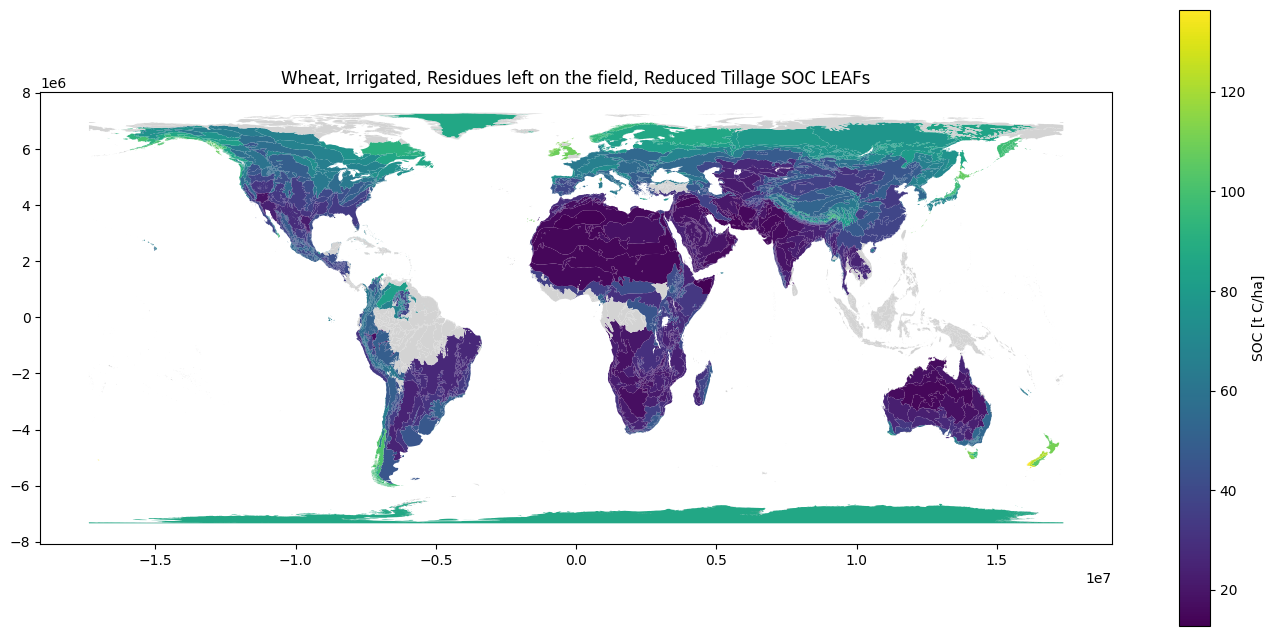

In [22]:
fig, ax = plt.subplots(figsize=(14, 8)) 
er_leafs_check.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "SOC [t C/ha]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title("Wheat, Irrigated, Residues left on the field, Reduced Tillage SOC LEAFs")
plt.tight_layout() 
plt.show()